#Lab Task 1: CLI based Tic-Tac-Toe

In [ ]:
def display_board(board):
    """Display the tic-tac-toe board"""
    print("\n ---+---+---")
    print("  " + board[1] + ' | ' + board[2] + ' | ' + board[3])
    print(" ---+---+---")
    print("  " + board[4] + ' | ' + board[5] + ' | ' + board[6])
    print(" ---+---+---")
    print("  " + board[7] + ' | ' + board[8] + ' | ' + board[9])
    print(" ---+---+---")


def get_valid_position(player_name, board):
    """Get a valid position from the player with full validation"""
    while True:
        try:
            position = int(input(f"\n{player_name}, choose a position from 1-9: "))

            # Check if number is in valid range
            if position not in range(1, 10):
                print("Choose a position from 1-9")
                continue

            # Check if position is already taken
            if board[position] in ['X', 'O']:
                print("That position is already taken! Choose another.")
                continue

            # If we get here, the input is valid
            return position

        except ValueError:
            print("Enter a number from 1-9")

def check_winner(board):
    """Checks for diagonal,horizonatal and vertical wins"""
        # Rows(positions 1-2-3, 4-5-6, 7-8-9)
    winning_combos = [
    [1, 2, 3], [4, 5, 6], [7, 8, 9],  # Rows
    [1, 4, 7], [2, 5, 8], [3, 6, 9],  # Columns
    [1, 5, 9], [3, 5, 7]              # Diagonals
    ]

    for combo in winning_combos:
        if board[combo[0]] == board[combo[1]] == board[combo[2]] and board[combo[0]] in ['X', 'O']:
            return board[combo[0]]

    return None

def check_draw(board):
    """Checks for draw"""
    for i in range(1,10):
        if board[i] not in ['X', 'O']:
            return False
    return True


def init():
    """Get player symbol choices (X or O)"""
    print("This is Tic-Tac-Toe")

    while True:
        choice = input("Player 1, choose either O or X:\n").upper()
        if choice in ['O', 'X']:
            player_1 = choice
            player_2 = 'X' if choice == 'O' else 'O'
            print(f"Player 1 is: {player_1}")
            print(f"Player 2 is: {player_2}")
            return player_1, player_2
        else:
            print("Choose either O or X")

def main():
    # Initialize the board
    board = [None, '1', '2', '3', '4', '5', '6', '7', '8', '9']

    # Get player symbols
    player_1, player_2 = init()

    # Show initial board
    display_board(board)

    # Main game loop
    while True:
        # Player 1's turn
        position = get_valid_position("Player 1", board)
        board[position] = player_1
        display_board(board)
        winner = check_winner(board)
        if winner:
            print(f"{winner} wins!")
            break
        draw = check_draw(board)
        if draw:
            print("It's a draw!")
            break
        # Player 2's turn
        position = get_valid_position("Player 2", board)
        board[position] = player_2
        display_board(board)
        winner = check_winner(board)
        if winner:
            print(f"{winner} wins!")
            break
        draw = check_draw(board)
        if draw:
            print("It's a draw!")
            break


# Run the game
if __name__ == "__main__":
    main()

This is Tic-Tac-Toe
Player 1, choose either O or X:
o
Player 1 is: O
Player 2 is: X

 ---+---+---
  1 | 2 | 3
 ---+---+---
  4 | 5 | 6
 ---+---+---
  7 | 8 | 9
 ---+---+---

Player 1, choose a position from 1-9: 1

 ---+---+---
  O | 2 | 3
 ---+---+---
  4 | 5 | 6
 ---+---+---
  7 | 8 | 9
 ---+---+---

Player 2, choose a position from 1-9: 4

 ---+---+---
  O | 2 | 3
 ---+---+---
  X | 5 | 6
 ---+---+---
  7 | 8 | 9
 ---+---+---

Player 1, choose a position from 1-9: 5

 ---+---+---
  O | 2 | 3
 ---+---+---
  X | O | 6
 ---+---+---
  7 | 8 | 9
 ---+---+---

Player 2, choose a position from 1-9: 4
That position is already taken! Choose another.

Player 2, choose a position from 1-9: 9

 ---+---+---
  O | 2 | 3
 ---+---+---
  X | O | 6
 ---+---+---
  7 | 8 | X
 ---+---+---

Player 1, choose a position from 1-9: 2

 ---+---+---
  O | O | 3
 ---+---+---
  X | O | 6
 ---+---+---
  7 | 8 | X
 ---+---+---

Player 2, choose a position from 1-9: 6

 ---+---+---
  O | O | 3
 ---+---+---
  X | O 

#Lab Task 2: GUI based Tic-Tac-Toe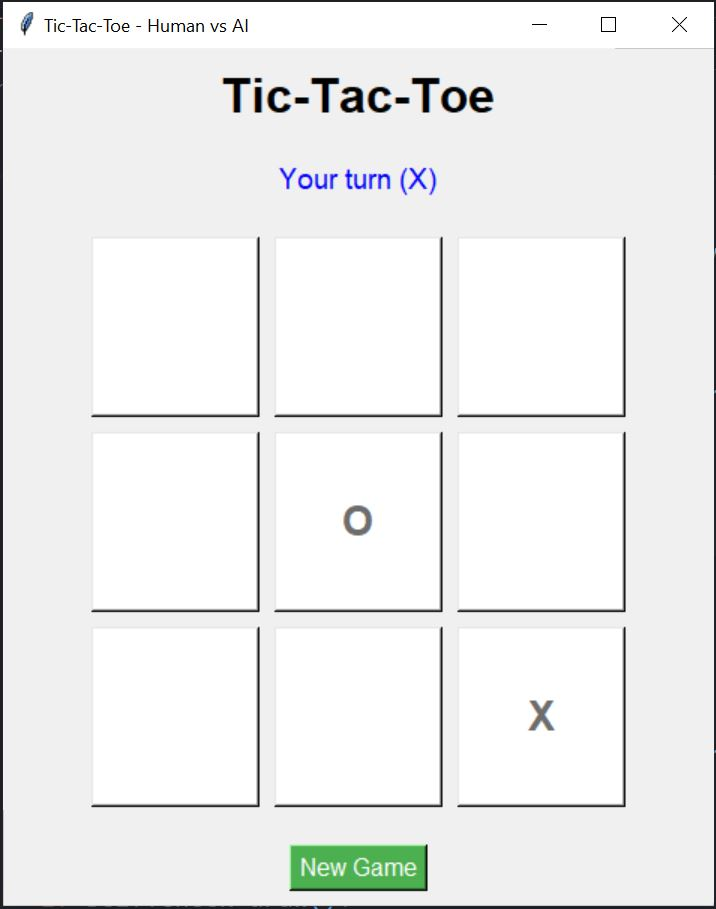

In [ ]:
import tkinter as tk
from tkinter import messagebox
import random


class TicTacToeGUI:
    def __init__(self, root):
        self.root = root
        self.root.title("Tic-Tac-Toe - Human vs AI")
        self.root.geometry("400x500")
        self.root.configure(bg="#f0f0f0")

        # Game variables
        self.board = [None, '1', '2', '3', '4', '5', '6', '7', '8', '9']
        self.human_player = 'X'
        self.ai_player = 'O'
        self.game_over = False
        self.human_turn = True

        # Create GUI elements
        self.create_widgets()

    def create_widgets(self):
        """Create all GUI widgets"""
        # Title label
        title_label = tk.Label(self.root, text="Tic-Tac-Toe", font=("Arial", 24, "bold"), bg="#f0f0f0")
        title_label.pack(pady=10)

        # Status label
        self.status_label = tk.Label(self.root, text="Your turn (X)", font=("Arial", 14), bg="#f0f0f0", fg="blue")
        self.status_label.pack(pady=10)

        # Board frame
        board_frame = tk.Frame(self.root, bg="#f0f0f0")
        board_frame.pack(pady=10)

        # Create button grid
        self.buttons = {}
        for i in range(1, 10):
            btn = tk.Button(board_frame, text='', font=("Arial", 20, "bold"), width=6, height=3,
                           command=lambda pos=i: self.on_button_click(pos), bg="white", activebackground="#e0e0e0")
            row = (i - 1) // 3
            col = (i - 1) % 3
            btn.grid(row=row, column=col, padx=5, pady=5)
            self.buttons[i] = btn

        # Reset button
        reset_btn = tk.Button(self.root, text="New Game", font=("Arial", 12), command=self.reset_game, bg="#4CAF50", fg="white")
        reset_btn.pack(pady=10)

    def on_button_click(self, position):
        """Handle button click"""
        if self.game_over:
            messagebox.showinfo("Game Over", "Game is over. Click 'New Game' to play again.")
            return

        if not self.human_turn:
            messagebox.showwarning("Not Your Turn", "Wait for AI to finish its turn.")
            return

        if self.board[position] in ['X', 'O']:
            messagebox.showwarning("Invalid Move", "That position is already taken!")
            return

        # Human player move
        self.board[position] = self.human_player
        self.update_button(position)

        # Check for winner or draw
        winner = self.check_winner()
        if winner:
            messagebox.showinfo("Game Over", f"You win! {self.human_player} wins!")
            self.game_over = True
            return

        if self.check_draw():
            messagebox.showinfo("Game Over", "It's a draw!")
            self.game_over = True
            return

        self.human_turn = False
        self.status_label.config(text="AI is thinking...", fg="orange")
        self.root.after(500, self.ai_move)

    def ai_move(self):
        """AI makes a move using minimax algorithm"""
        # Try to win
        best_move = self.find_best_move()

        if best_move:
            self.board[best_move] = self.ai_player
            self.update_button(best_move)

            # Check for winner or draw
            winner = self.check_winner()
            if winner:
                messagebox.showinfo("Game Over", f"AI wins! {self.ai_player} wins!")
                self.game_over = True
                return

            if self.check_draw():
                messagebox.showinfo("Game Over", "It's a draw!")
                self.game_over = True
                return

            self.human_turn = True
            self.status_label.config(text="Your turn (X)", fg="blue")

    def find_best_move(self):
        """Find the best move using minimax algorithm"""
        best_score = float('-inf')
        best_move = None

        for i in range(1, 10):
            if self.board[i] not in ['X', 'O']:
                self.board[i] = self.ai_player
                score = self.minimax(0, False)
                self.board[i] = str(i)

                if score > best_score:
                    best_score = score
                    best_move = i

        return best_move

    def minimax(self, depth, is_maximizing):
        """Minimax algorithm for optimal AI play"""
        winner = self.check_winner()

        if winner == self.ai_player:
            return 10 - depth
        elif winner == self.human_player:
            return depth - 10
        elif self.check_draw():
            return 0

        if is_maximizing:
            best_score = float('-inf')
            for i in range(1, 10):
                if self.board[i] not in ['X', 'O']:
                    self.board[i] = self.ai_player
                    score = self.minimax(depth + 1, False)
                    self.board[i] = str(i)
                    best_score = max(score, best_score)
            return best_score
        else:
            best_score = float('inf')
            for i in range(1, 10):
                if self.board[i] not in ['X', 'O']:
                    self.board[i] = self.human_player
                    score = self.minimax(depth + 1, True)
                    self.board[i] = str(i)
                    best_score = min(score, best_score)
            return best_score

    def check_winner(self):
        """Check for a winner"""
        winning_combos = [
            [1, 2, 3], [4, 5, 6], [7, 8, 9],  # Rows
            [1, 4, 7], [2, 5, 8], [3, 6, 9],  # Columns
            [1, 5, 9], [3, 5, 7]              # Diagonals
        ]

        for combo in winning_combos:
            if (self.board[combo[0]] == self.board[combo[1]] == self.board[combo[2]] and
                self.board[combo[0]] in ['X', 'O']):
                return self.board[combo[0]]

        return None

    def check_draw(self):
        """Check for a draw"""
        for i in range(1, 10):
            if self.board[i] not in ['X', 'O']:
                return False
        return True

    def update_button(self, position):
        """Update button display"""
        self.buttons[position].config(text=self.board[position], state='disabled')
        if self.board[position] == 'X':
            self.buttons[position].config(fg="blue")
        else:
            self.buttons[position].config(fg="red")

    def reset_game(self):
        """Reset the game"""
        self.board = [None, '1', '2', '3', '4', '5', '6', '7', '8', '9']
        self.game_over = False
        self.human_turn = True
        self.status_label.config(text="Your turn (X)", fg="blue")

        for i in range(1, 10):
            self.buttons[i].config(text='', state='normal', fg="black")


if __name__ == "__main__":
    root = tk.Tk()
    game = TicTacToeGUI(root)
    root.mainloop()

TclError: no display name and no $DISPLAY environment variable